In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from  typing import Callable 
NOMBRE_PERIODE = 5
NOMBRE_GROUPE = 7
ECHELLE_POINT = 0.005

In [6]:
class Groupe:
    def __init__(self, nomGroupe: str, prixMoyen: float, imageQualite: float, ca: float):
        self.nomGroupe = nomGroupe
        self.prixMoyen = prixMoyen
        self.imageQualite = imageQualite
        self.ca = ca

In [7]:
def traiter(df: pd.DataFrame) -> tuple[list[float], list[float]]:
    tab = df.iloc[5:9]
    imageQualite = tab.iloc[-1].iloc[4:-1].dropna()
    prix = tab.iloc[0].iloc[4:-1].dropna()
    imageQualite = imageQualite.apply(lambda x: float(x.strip().replace(',', '.'))).to_list() 
    prix = prix.apply(lambda x: float(x.strip().replace(',', '.'))).to_list()
    return imageQualite, prix

obtenirCA : Callable[[pd.DataFrame,int],list[float]] =  lambda ca, i : ca.iloc[i].apply(lambda x: x * ECHELLE_POINT ).to_list()

creerChampGroupe : Callable[[pd.DataFrame],list[float]] = lambda df : [nomGroupe[:3] for nomGroupe in df.columns[4:-2]]

def filtrerSoiMemeEtGroupesProf(listContatene : list[Groupe], groupe : Groupe) -> list[Groupe] :
    listContatene.pop()
    listContatene.pop(4)
    listContatene.remove(groupe)
    return listContatene


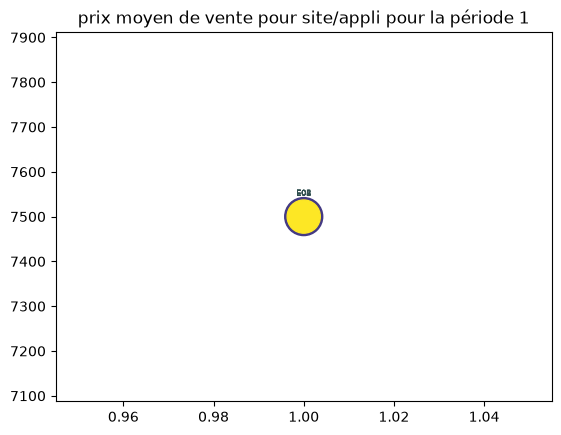

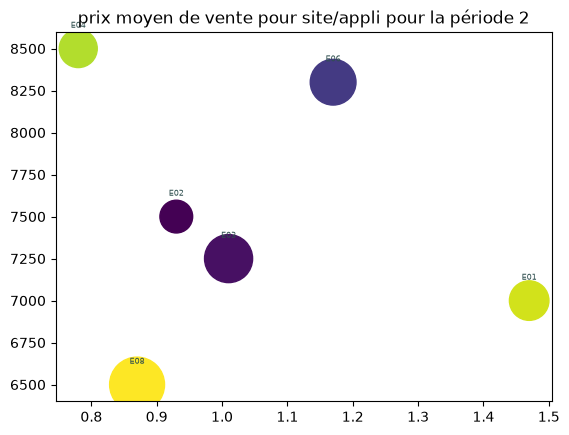

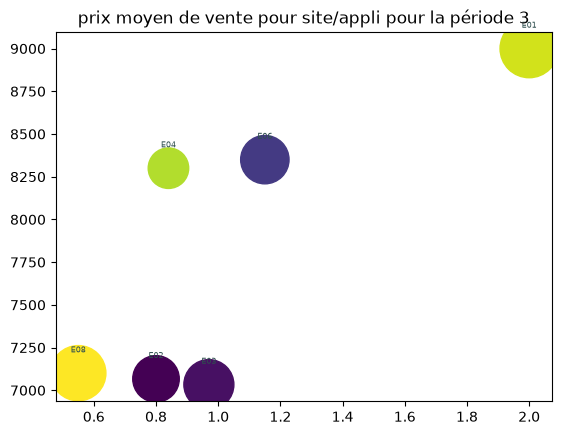

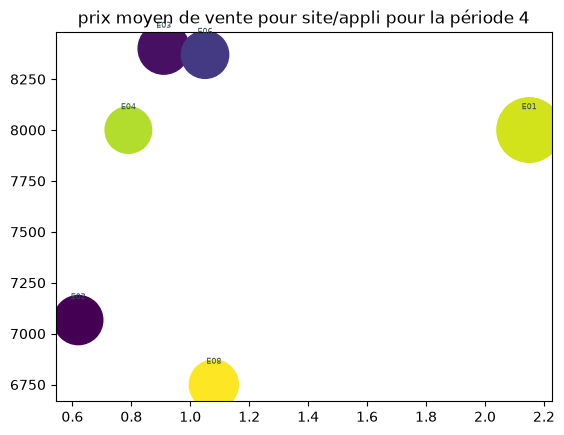

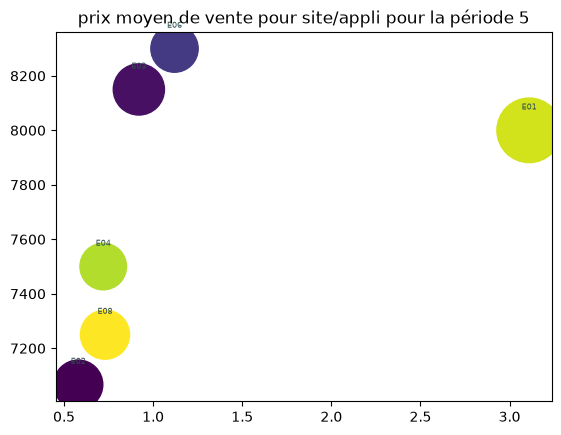

In [8]:
nomSonPropreGroupe = "E07"
ca = pd.read_csv("chiffreDAffaire.csv")
colors = np.random.rand(NOMBRE_GROUPE - 1) * 250

for i in range(0, NOMBRE_PERIODE):
    df = pd.read_csv(f"etude/exportMarketResearch({i}).csv", sep=';')
    
    if i == NOMBRE_PERIODE - 1: ligneCAPeriode = obtenirCA(ca, i)
    else: ligneCAPeriode = obtenirCA(ca, i + 1)
    imageQualite, prix = traiter(df)
    champGroupe = creerChampGroupe(df)
    
    concatene = list(zip(champGroupe, prix, imageQualite, ligneCAPeriode))
    listeGroupe = [Groupe( nomGroupe, prixGroupe, imageQualiteGroupe, caGroupe) for nomGroupe, prixGroupe, imageQualiteGroupe, caGroupe in concatene]
    sonPropreGroupe = tuple(filter(lambda groupe: groupe.nomGroupe == nomSonPropreGroupe,listeGroupe))
    if len(sonPropreGroupe) != 1: raise ValueError("le nom du groupe est incorrect")
    else: sonPropreGroupe = sonPropreGroupe[0]
    
    listeGroupe = filtrerSoiMemeEtGroupesProf(listeGroupe, sonPropreGroupe)
    imageQualite = [groupe.imageQualite for groupe in listeGroupe]
    prix = [groupe.prixMoyen for groupe in listeGroupe]
    ligneCAPeriode = [groupe.ca for groupe in listeGroupe]
    
    for groupe in listeGroupe:
        plt.annotate(
            groupe.nomGroupe,
            xy=(groupe.imageQualite, groupe.prixMoyen),
            textcoords="offset points",
            xytext=(0, 15),
            ha='center',
            fontsize=6,
            color='darkslategray'
        )
    plt.title(f"prix moyen de vente pour site/appli pour la période {i + 1}")
    plt.scatter(imageQualite, prix, s=ligneCAPeriode, c=colors)
    plt.show()
